In [13]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings



In [14]:
# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [15]:

# Generamos los datos: dos círculos concéntricos
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)




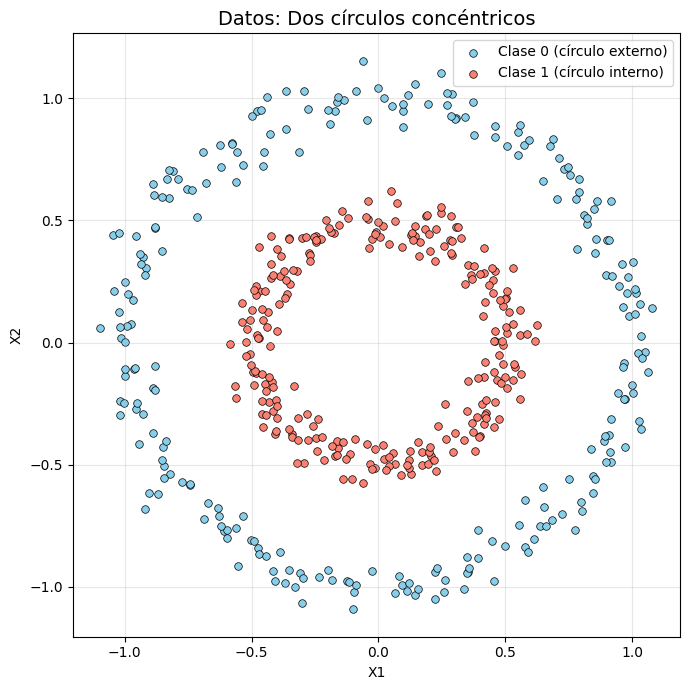

In [16]:
# Visualización
plt.figure(figsize=(7, 7))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0 (círculo externo)", edgecolors='k', s=30, linewidths=0.5)
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon",  label="Clase 1 (círculo interno)", edgecolors='k', s=30, linewidths=0.5)
plt.title("Datos: Dos círculos concéntricos", fontsize=14)
plt.xlabel("X1"); plt.ylabel("X2")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
print(f"Total de muestras : {X.shape[0]}")
print(f"Clases            : {np.unique(Y)}")
print(f"Distribución      : {np.bincount(Y)}")

Total de muestras : 500
Clases            : [0 1]
Distribución      : [250 250]


División de datos
  Entrenamiento : 349 muestras (69.8%)
  Validación    : 76  muestras (15.2%)
  Test          : 75  muestras (15.0%)


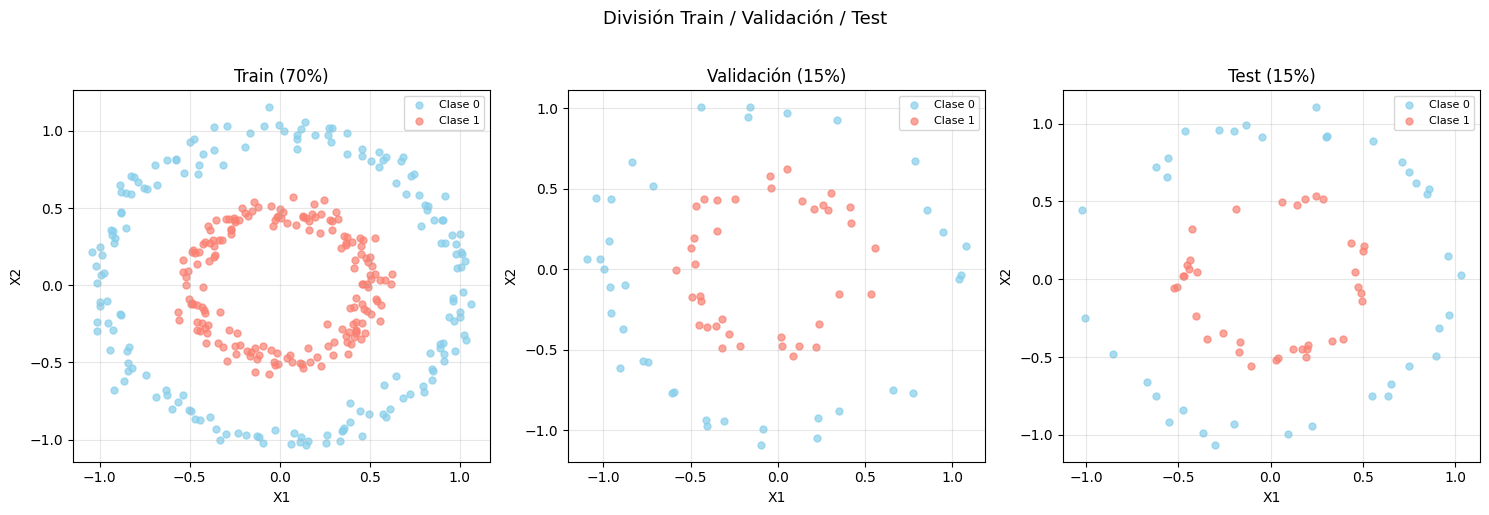


Normalización aplicada — Media: [-0. -0.] | Std: [1. 1.]


In [25]:
# Paso 1: separar 85% (train+val) y 15% test
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42, stratify=Y
)

# Paso 2: del 85% restante, separar ~17.6% para val (= 15% del total)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.1765, random_state=42, stratify=Y_temp
)

print("División de datos")
print(f"  Entrenamiento : {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validación    : {X_val.shape[0]}  muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test          : {X_test.shape[0]}  muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Normalización (fit solo en train) — ANTES de la visualización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Visualización usando los datos ORIGINALES (sin escalar)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = [(X_train, Y_train, "Train (70%)"),
          (X_val,   Y_val,   "Validación (15%)"),
          (X_test,  Y_test,  "Test (15%)")]

for ax, (X_s, Y_s, title) in zip(axes, splits):
    ax.scatter(X_s[Y_s==0, 0], X_s[Y_s==0, 1], c="skyblue", label="Clase 0", alpha=0.7, s=25)
    ax.scatter(X_s[Y_s==1, 0], X_s[Y_s==1, 1], c="salmon",  label="Clase 1", alpha=0.7, s=25)
    ax.set_title(title, fontsize=12); ax.set_xlabel("X1"); ax.set_ylabel("X2")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("División Train / Validación / Test", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"\nNormalización aplicada — Media: {X_train_scaled.mean(axis=0).round(3)} | Std: {X_train_scaled.std(axis=0).round(3)}")

In [ ]:
modelo_profundo = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(16, activation='relu', name='capa_oculta_1'),
    layers.Dense(16, activation='relu', name='capa_oculta_2'),
    layers.Dense(8,  activation='relu', name='capa_oculta_3'),
    layers.Dense(1,  activation='sigmoid', name='salida')
], name="Modelo_Profundo")

modelo_profundo.summary()

modelo_profundo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

historia_profundo = modelo_profundo.fit(
    X_train_scaled, Y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_scaled, Y_val),
    verbose=1
)

loss_p, acc_p = modelo_profundo.evaluate(X_test_scaled, Y_test, verbose=1)
print(f"\nModelo Profundo → Test Accuracy: {acc_p*100:.2f}%")

Model: "Modelo_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)


Modelo Profundo → Test Accuracy: 100.00%
